# About This notebook

This notebook continues the Exploratory Data Analysis from the previous notebook. 

Here, we import data from the `stage_01` schema from the PostgreSQL database `train_reward_compare`. 

When finished, the notebook inserts the data into the next schema: `stage_02`.

## Links to Data

[https://www.onetcenter.org/database.html#all-files](https://www.onetcenter.org/database.html#all-files)

[https://www.bls.gov/oes/](https://www.bls.gov/oes/)

# Project Setup

## Import and Verifications

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlalchemy

In [2]:
print(sqlalchemy.__version__)
print(np.__version__)

2.0.48
2.1.0


In [3]:
from sqlalchemy import create_engine, inspect
from sqlalchemy import text
from sqlalchemy.schema import CreateSchema
from sqlalchemy import BigInteger, Column, Integer, String, Float, Boolean, Text, Date
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column

In [4]:
# The following imports are a match from the previous Springboard EDA project

import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
import warnings
 
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

## Create SQL Engine and Test Connection

In [5]:
engine = create_engine('postgresql+psycopg2://postgres@localhost/train_reward_compare')

In [6]:
with engine.connect() as conn:
    result = conn.execute(text("select count(*) from onet.occupation_data"))
    print(result.fetchone())

(1016,)


# Import Data from PostgreSQL

## List of Imports

We start by bringing the previous dataset stored in the `stage_01` schema.

- full_df

## Import Dataset

In [7]:
# Data Schema for Import
schema_name_import = 'stage_01'

# Data Table Names
full_df_table_name = 'full_df'

In [8]:
full_df = pd.DataFrame()

with engine.connect() as conn:
    full_df = pd.read_sql_table(full_df_table_name, schema=schema_name_import, con=engine, index_col='id')

## Prepping Data

Our focus for this Exploratory Data Analysis is the relationship between investment and reward in a career path.

Let's narrow down our dataset to those aspects that are relevant.

### Inspect the Data

In [9]:
full_df.head(4)

,onetsoc_code,occ_code,occupation_title,occ_title,o_group,category,category_description,data_value,a_mean,h_mean
id,,,,,,,,,,
1,11-1011,11-1010,Chief Executives,Chief Executives,broad,1.0,Less than a High School Diploma,0.00,262930.0,126.41
2,11-1011,11-1010,Chief Sustainability Officers,Chief Executives,broad,1.0,Less than a High School Diploma,0.00,262930.0,126.41
3,11-1011,11-1010,Chief Executives,Chief Executives,broad,2.0,High School Diploma - or the equivalent (for e...,4.46,262930.0,126.41
4,11-1011,11-1010,Chief Sustainability Officers,Chief Executives,broad,2.0,High School Diploma - or the equivalent (for e...,4.46,262930.0,126.41


In [10]:
full_df.shape

(9324, 10)

In [11]:
full_df.describe()

,category,data_value,a_mean,h_mean
count,9324.000000,9324.000000,9289.000000,8673.000000
mean,6.532282,7.893373,78583.059533,37.164161
std,3.450191,16.694828,46087.073889,22.168276
min,1.000000,0.000000,30830.000000,14.820000
25%,4.000000,0.000000,49240.000000,23.330000
50%,7.000000,0.000000,65770.000000,30.730000
75%,10.000000,7.430000,93890.000000,44.070000
max,12.000000,100.000000,360240.000000,173.190000


In [12]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9324 entries, 1 to 9322
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   onetsoc_code          9324 non-null   object 
 1   occ_code              9324 non-null   object 
 2   occupation_title      9324 non-null   object 
 3   occ_title             9324 non-null   object 
 4   o_group               9324 non-null   object 
 5   category              9324 non-null   float64
 6   category_description  9324 non-null   object 
 7   data_value            9324 non-null   float64
 8   a_mean                9289 non-null   float64
 9   h_mean                8673 non-null   float64
dtypes: float64(4), object(6)
memory usage: 801.3+ KB


### Resolving NaN Values

The dataset contains instances where either the annual or the hourly were not known.

In [13]:
full_df.isna().sum()

onetsoc_code              0
occ_code                  0
occupation_title          0
occ_title                 0
o_group                   0
category                  0
category_description      0
data_value                0
a_mean                   35
h_mean                  651
dtype: int64

In [14]:
full_df[(full_df['a_mean'].isna() == True) & (full_df['h_mean'].isna() == True)]

,onetsoc_code,occ_code,occupation_title,occ_title,o_group,category,category_description,data_value,a_mean,h_mean
id,,,,,,,,,,


From what we can see here, either `a_mean` or `h_mean` is NaN, but never both.

Only `35` values in the `a_mean` column are Nan. 

Let's interpolate the annual salary for those `35` rows by calculating against the average number of work hours in a year.

In [15]:
avg_annual_hrs = 1800

In [16]:
full_df['a_mean'] = np.where(full_df['a_mean'].isna() == True, full_df['h_mean'] * avg_annual_hrs, full_df['a_mean'])

In [17]:
full_df.isna().sum()

onetsoc_code              0
occ_code                  0
occupation_title          0
occ_title                 0
o_group                   0
category                  0
category_description      0
data_value                0
a_mean                    0
h_mean                  651
dtype: int64

Drop the `h_mean` column as we no longer need it.

In [18]:
full_df = full_df.drop(columns=['h_mean'])

### Creating a Career-Cost Estimate

As mentioned in the previous notebook, we have discovered along the way of our EDA that the O*NET dataset's relevant information is discrete, rather than continuous.

We can visualize what we have.

We can't perform true linear regression with discrete data.

For the purposes of the exercise of this dataset, we can create an approximation, with the understanding that this is not a truly viable scientific measurement.

What we want to do is create a scale that shows how much education is required to become sufficiently proficient in a career field, according to the O*NET survey respondents.

For each unique `onetsoc_code`, we'll multiple the `category` value (which is on a scale of 0 to 12) by the `data_value`, and sum those together.

We'll use this information to create a new dataframe that has one row per `onetsoc_code`, and we'll have a column for this new approximated scale value.

In [19]:
full_df['education_sum'] = full_df['category'] * full_df['data_value']

In [20]:
full_df.head(3)

,onetsoc_code,occ_code,occupation_title,occ_title,o_group,category,category_description,data_value,a_mean,education_sum
id,,,,,,,,,,
1,11-1011,11-1010,Chief Executives,Chief Executives,broad,1.0,Less than a High School Diploma,0.00,262930.0,0.00
2,11-1011,11-1010,Chief Sustainability Officers,Chief Executives,broad,1.0,Less than a High School Diploma,0.00,262930.0,0.00
3,11-1011,11-1010,Chief Executives,Chief Executives,broad,2.0,High School Diploma - or the equivalent (for e...,4.46,262930.0,8.92


### Unifying the Titles

Earlier, we found that there were slight mismatches between the sometimes-more-specific O*NET dataset and the BLS dataset.

We generalized to the BLS dataset in these scenarios.

Unfortunately, we can see in the above `.head()` calls that there are duplicate `onetsoc_code` values, where specific information is retained but the relevant target data is lost.

We will have to drop these duplicates. Before we can do this, we need to create a column that captures the most relevant title.

If the O*NET and BLS code columns match, we know that the most specific title is correct.

If the O*NET and BLS code columns do not match, we want to take the more generalized BLS title.

Once we have finalized our titles, we'll drop duplicates.

In [21]:
full_df['accepted_title'] = np.where(full_df['onetsoc_code'].str == full_df['occ_code'].str, full_df['occupation_title'], full_df['occ_title'])

In [22]:
full_df = full_df[['onetsoc_code', 'occ_code', 'occupation_title', 'occ_title', 'accepted_title', 'o_group',
       'category', 'category_description', 'data_value', 'a_mean',
       'education_sum']]

In [23]:
full_df = full_df.drop(columns=['occupation_title', 'occ_title'])

In [24]:
full_df.duplicated().sum()

np.int64(766)

In [25]:
full_df.drop_duplicates(subset=None, keep='first', inplace=True, ignore_index=False)

In [26]:
full_df.duplicated().sum()

np.int64(0)

### Condensing Rows

There are now many duplicate rows due to the fact that the O*NET database often had several specific rows where only one general BLS row could be matched. 

Condense the rows so that we have only one row per unique code.

In [27]:
full_df.shape

(8558, 9)

In [28]:
full_df['onetsoc_code'].unique().shape

(730,)

In [29]:
condensed_df = pd.DataFrame(full_df.groupby(['onetsoc_code'])['education_sum'].sum().sort_values(ascending=False))

In [30]:
condensed_df.shape

(730, 1)

In [31]:
condensed_df.head(3)

,education_sum
onetsoc_code,
29-1221,1177.03
29-1218,1170.56
29-1022,1164.24


In [32]:
condensed_df = pd.merge(condensed_df, full_df[['onetsoc_code', 'occ_code', 'accepted_title', 'a_mean']], left_on='onetsoc_code', right_on='onetsoc_code') 

In [33]:
condensed_df.shape

(8558, 5)

In [34]:
condensed_df = condensed_df.drop_duplicates(subset=['onetsoc_code', 'accepted_title'], keep='first')

In [35]:
condensed_df.shape

(730, 5)

In [36]:
condensed_df['onetsoc_code'].nunique()

730

In [37]:
condensed_df.sort_values(by='education_sum', ascending=False).head(5)

,onetsoc_code,education_sum,occ_code,accepted_title,a_mean
0,29-1221,1177.03,29-1221,"Pediatricians, General",222340.0
12,29-1218,1170.56,29-1218,Obstetricians and Gynecologists,281130.0
24,29-1022,1164.24,29-1022,Oral and Maxillofacial Surgeons,360240.0
36,29-1211,1160.55,29-1211,Anesthesiologists,336640.0
48,29-1214,1158.62,29-1214,Emergency Medicine Physicians,320700.0


# Visualizing the Data

## Initial Visual Observations

Let's try plotting the data.

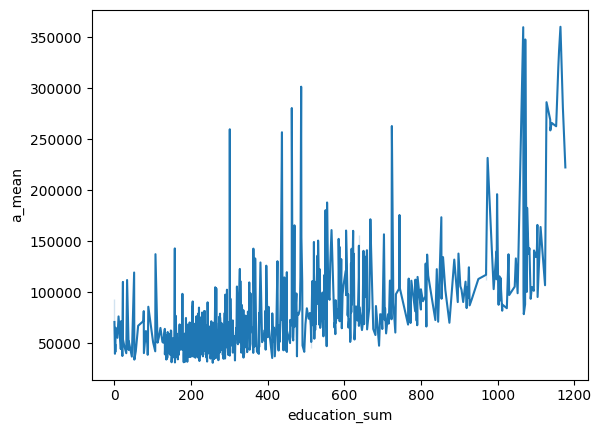

In [38]:
fig, ax = plt.subplots()
_ = sns.lineplot(x='education_sum', y='a_mean', data=condensed_df)
plt.show()

## Observing High Earners

Out of curiosity, let's look solely at high-income earners.

In [39]:
high_earn_df = condensed_df[condensed_df['a_mean'] >= 150000]

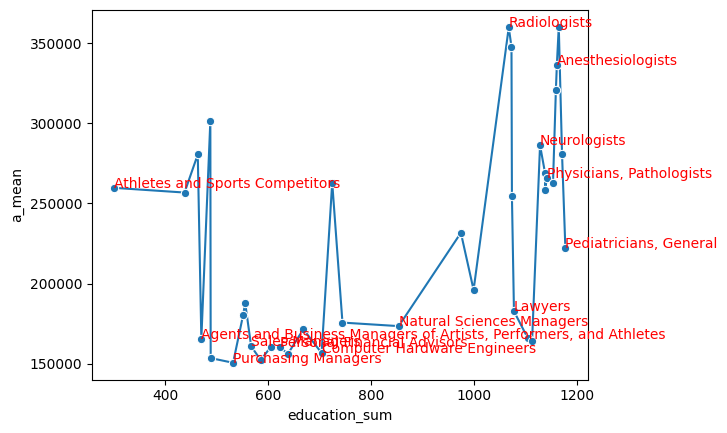

In [40]:
fig, ax = plt.subplots()
_ = sns.lineplot(x='education_sum', y='a_mean', data=high_earn_df, marker='o')

# Loop through the data to add labels from another column
# Print only one third of the values
for i in range(high_earn_df.shape[0]):
    if (i % 3 == 0):
        plt.text(x=high_earn_df['education_sum'].iloc[i] + 0.1,  # Offset x to the right
                 y=high_earn_df['a_mean'].iloc[i] + 0.1,  # Offset y slightly up
                 s=high_earn_df['accepted_title'].iloc[i],    # The text from your other column
                 fontdict=dict(color='red', size=10))
plt.show()

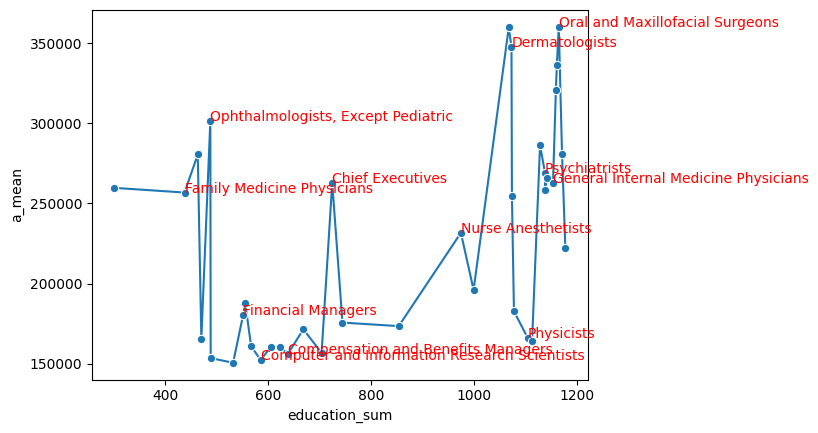

In [41]:
fig, ax = plt.subplots()
_ = sns.lineplot(x='education_sum', y='a_mean', data=high_earn_df, marker='o')

# Loop through the data to add labels from another column
# Print only the second third of the values
for i in range(high_earn_df.shape[0]):
    if (i % 3 == 2):
        plt.text(x=high_earn_df['education_sum'].iloc[i] + 0.1,  # Offset x to the right
                 y=high_earn_df['a_mean'].iloc[i] + 0.1,  # Offset y slightly up
                 s=high_earn_df['accepted_title'].iloc[i],    # The text from your other column
                 fontdict=dict(color='red', size=10))
plt.show()

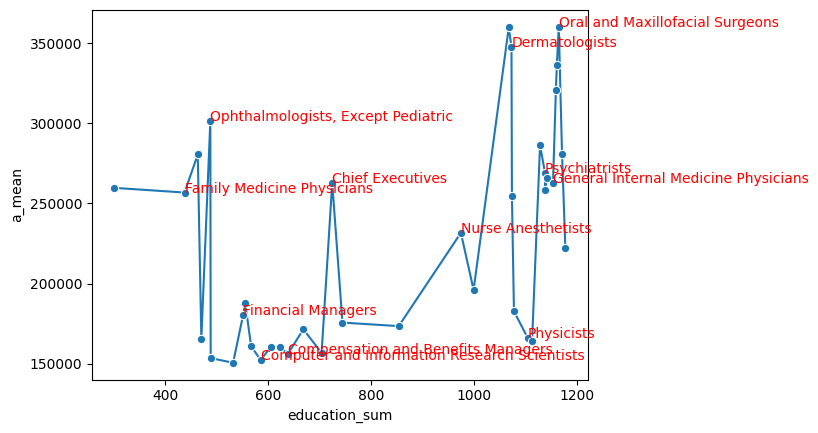

In [42]:
fig, ax = plt.subplots()
_ = sns.lineplot(x='education_sum', y='a_mean', data=high_earn_df, marker='o')

# Loop through the data to add labels from another column
# Print only the second third of the values
for i in range(high_earn_df.shape[0]):
    if (i % 3 == 2):
        plt.text(x=high_earn_df['education_sum'].iloc[i] + 0.1,  # Offset x to the right
                 y=high_earn_df['a_mean'].iloc[i] + 0.1,  # Offset y slightly up
                 s=high_earn_df['accepted_title'].iloc[i],    # The text from your other column
                 fontdict=dict(color='red', size=10))
plt.show()

In [43]:
high_earn_df[['accepted_title', 'education_sum', 'a_mean']].sort_values(by='education_sum', ascending=True)

,accepted_title,education_sum,a_mean
4597,Athletes and Sports Competitors,301.10,259750.0
3284,Family Medicine Physicians,437.26,256830.0
3056,"Airline Pilots, Copilots, and Flight Engineers",462.95,280570.0
3009,"Agents and Business Managers of Artists, Perfo...",469.90,165600.0
2899,"Ophthalmologists, Except Pediatric",487.38,301500.0
2888,Petroleum Engineers,488.04,153560.0
2530,Purchasing Managers,531.60,150630.0
2326,Financial Managers,551.08,180470.0
2290,Computer and Information Systems Managers,555.03,187990.0
2218,Sales Managers,566.66,160930.0


## Statistical Analysis

We perform a few standard statistical analyses.

In [44]:
condensed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 730 entries, 0 to 8548
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   onetsoc_code    730 non-null    object 
 1   education_sum   730 non-null    float64
 2   occ_code        730 non-null    object 
 3   accepted_title  730 non-null    object 
 4   a_mean          730 non-null    float64
dtypes: float64(2), object(3)
memory usage: 34.2+ KB


In [45]:
df = condensed_df[['education_sum', 'a_mean']]

### Pairplot

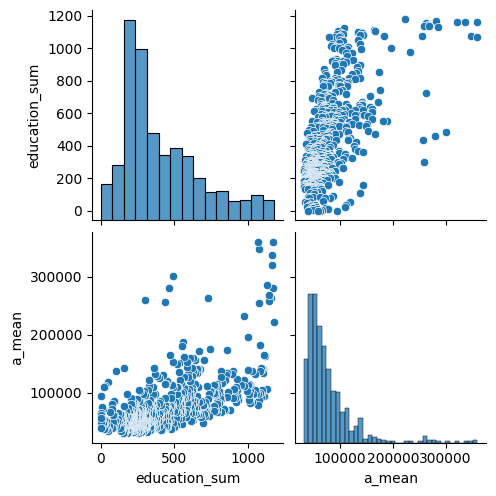

In [46]:
_ = sns.pairplot(df)
plt.show()
_.savefig('2026-05-01-00-pairplot.png')

### Heatmap

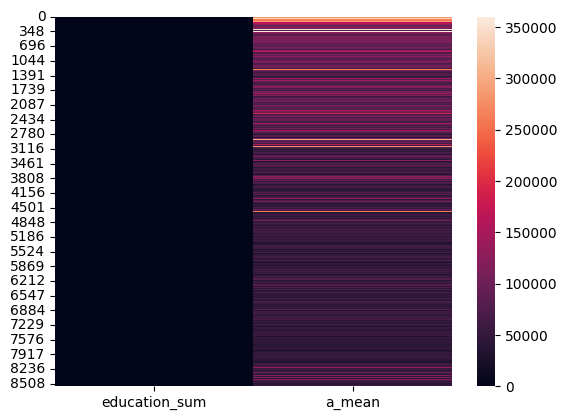

<Figure size 640x480 with 0 Axes>

In [47]:
# Make a heatmap of the data 
_ = sns.heatmap(df)
plt.show()
plt.savefig("2026-05-01-01-heatmap.png", dpi=300, bbox_inches='tight')

### Scatterplots

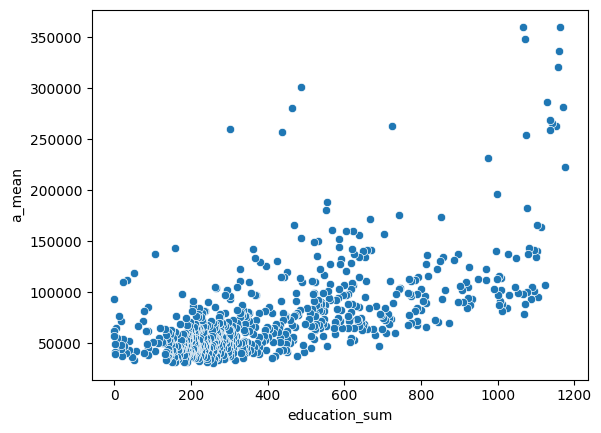

In [48]:
# Plot density
_ = sns.scatterplot(x='education_sum', y='a_mean', data=df)
plt.show()

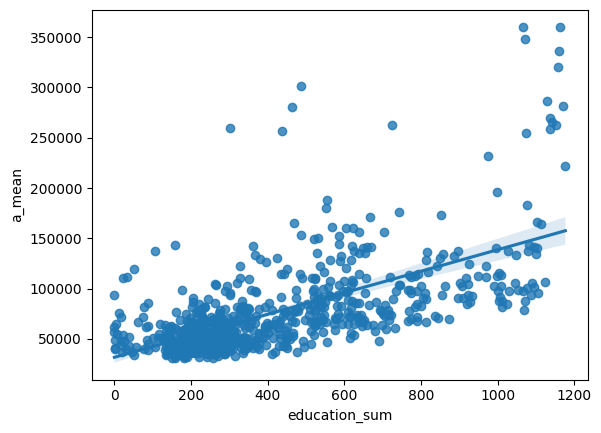

In [49]:
# Call the regplot method on sns object
_ = sns.regplot(x='education_sum', y='a_mean', data=df)

# Modeling

## Train, Test, Split

As noted above, there is a positive linear relationship between the two variables, `education_sum` and `a_mean`.

We now divide the data into training and test sets and create a prediction model.

In [50]:
X = pd.DataFrame(df['education_sum'])
y = pd.DataFrame(df['a_mean'])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [52]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(547, 1)
(183, 1)
(547, 1)
(183, 1)


## Making a Linear Regression Model

In [53]:
rModel = linear_model.LinearRegression()

In [54]:
rModel.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
